In [ ]:
import mlflow
import pandas as pd

df = pd.read_csv('d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/notebook/dataset_engineered/data_engineered.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 73 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Id                    180519 non-null  int64  
 12  Customer Segment              

# Late Shipment Risk

## Preprocessing

### Data Cleaning

In [29]:
df_risk = df.copy()
df_risk.drop_duplicates(inplace=True)

In [30]:
# Missing Data Handling
df_risk.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
                                ..
city_mismatch                    0
is_product_inactive              0
high_discount_flag               0
negative_profit_flag             0
negative_margin_flag             0
Length: 73, dtype: int64

In [31]:
# Noisy Data / Outlier Detection (IQR)

outlier_summary = {}

cols = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'actual_delay',
    'shipping_speed_ratio'
]

for col in cols:
    Q1 = df_risk[col].quantile(0.25)
    Q3 = df_risk[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_flag = (
        (df_risk[col] < lower_bound) | 
        (df_risk[col] > upper_bound)
    )

    df_risk[f'{col}_outlier'] = outlier_flag.astype(int)

    outlier_summary[col] = {
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_outliers": int(outlier_flag.sum()),
        "percentage": round(outlier_flag.mean() * 100, 2)
    }

# ubah ke DataFrame biar rapi
outlier_summary_df = pd.DataFrame(outlier_summary).T

# tampilkan
outlier_summary_df.sort_values(by='percentage', ascending=False)

,lower_bound,upper_bound,n_outliers,percentage
actual_delay,-1.500000,2.500000,35701.0,19.78
shipping_speed_ratio,-1.124997,3.874995,4657.0,2.58
Days for shipping (real),-2.500000,9.500000,0.0,0.00
Days for shipment (scheduled),-1.000000,7.000000,0.0,0.00


#### Splitting Data

In [32]:
# Splitting data
from sklearn.model_selection import GroupShuffleSplit

target = 'Late_delivery_risk'
leakage_cols = [
    "Late_delivery_risk",
    "Days for shipping (real)",
    "Delivery Status",
    "actual_delay",
    "is_late",
    "is_early",
    "severe_delay",
    "shipping_speed_ratio"
]

X = df.drop(columns=[col for col in leakage_cols if col in df.columns])
y = df[target]

groups = df_risk["Order Id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)
train_idx, temp_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]

X_temp = X.iloc[temp_idx]
y_temp = y.iloc[temp_idx]
groups_temp = groups.iloc[temp_idx]

gss_valid_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

valid_idx, test_idx = next(gss_valid_test.split(X_temp, y_temp, groups_temp))

X_valid = X_temp.iloc[valid_idx]
y_valid = y_temp.iloc[valid_idx]

X_test = X_temp.iloc[test_idx]
y_test = y_temp.iloc[test_idx]

id_cols = [
    "Order Id",
    "Order Item Id",
    "Customer Id",
    "Product Card Id",
    "Order Item Cardprod Id",
    "Category Id",
    "Department Id"
]

X_train = X_train.drop(columns=[col for col in id_cols if col in X_train.columns])
X_valid = X_valid.drop(columns=[col for col in id_cols if col in X_valid.columns])
X_test  = X_test.drop(columns=[col for col in id_cols if col in X_test.columns])


### Data Transformation

#### Encoding

In [33]:
category_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

In [35]:
# Encoding Categorical Variables
# Frequency Encoding + Rare Category Handling

X_train_cat = X_train[category_cols].copy()
X_valid_cat = X_valid[category_cols].copy()
X_test_cat  = X_test[category_cols].copy()

freq_maps = {}
rare_maps = {}

rare_threshold = 20

for col in category_cols:
    # 1. Missing value berdasarkan train
    mode_value = X_train_cat[col].mode()[0]

    X_train_cat[col] = X_train_cat[col].fillna(mode_value)
    X_valid_cat[col] = X_valid_cat[col].fillna(mode_value)
    X_test_cat[col]  = X_test_cat[col].fillna(mode_value)

    # 2. Rare category berdasarkan train
    counts = X_train_cat[col].value_counts()
    valid_categories = counts[counts >= rare_threshold].index

    X_train_cat[col] = X_train_cat[col].where(
        X_train_cat[col].isin(valid_categories), 
        'Rare'
    )

    X_valid_cat[col] = X_valid_cat[col].where(
        X_valid_cat[col].isin(valid_categories), 
        'Rare'
    )

    X_test_cat[col] = X_test_cat[col].where(
        X_test_cat[col].isin(valid_categories), 
        'Rare'
    )

    rare_maps[col] = counts[counts < rare_threshold].index.tolist()

    # 3. Frequency encoding berdasarkan train setelah rare handling
    freq_map = X_train_cat[col].value_counts(normalize=True)

    X_train_cat[col + '_freq'] = X_train_cat[col].map(freq_map)
    X_valid_cat[col + '_freq'] = X_valid_cat[col].map(freq_map).fillna(0)
    X_test_cat[col + '_freq']  = X_test_cat[col].map(freq_map).fillna(0)

    freq_maps[col] = freq_map.to_dict()

# 4. Ambil kolom hasil encoding saja
encoded_cols = [col + '_freq' for col in category_cols]

X_train_cat = X_train_cat[encoded_cols]
X_valid_cat = X_valid_cat[encoded_cols]
X_test_cat  = X_test_cat[encoded_cols]

In [36]:
X_train_num = X_train[numeric_cols].copy()
X_valid_num = X_valid[numeric_cols].copy()
X_test_num  = X_test[numeric_cols].copy()

X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_valid_processed = pd.concat([X_valid_num, X_valid_cat], axis=1)
X_test_processed  = pd.concat([X_test_num, X_test_cat], axis=1)

In [ ]:
# Normalization and Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_processed[numeric_cols])
X_valid_num_scaled = scaler.transform(X_valid_processed[numeric_cols])
X_test_num_scaled  = scaler.transform(X_test_processed[numeric_cols])

# Convert balik ke DataFrame
X_train_num_scaled = pd.DataFrame(
    X_train_num_scaled,
    columns=X_train_processed.columns,
    index=X_train_processed.index
)

X_valid_num_scaled = pd.DataFrame(
    X_valid_num_scaled,
    columns=X_valid_processed.columns,
    index=X_valid_processed.index
)

X_test_num_scaled = pd.DataFrame(
    X_test_num_scaled,
    columns=X_test_processed.columns,
    index=X_test_processed.index
)

X_train_processed[numeric_cols] = X_train_num_scaled
X_valid_processed[numeric_cols] = X_valid_num_scaled
X_test_processed[numeric_cols]  = X_test_num_scaled

In [41]:
print(X_train_processed.shape)
print(X_valid_processed.shape)
print(X_test_processed.shape)

(126758, 58)
(26594, 58)
(27167, 58)


#### Feature Selection

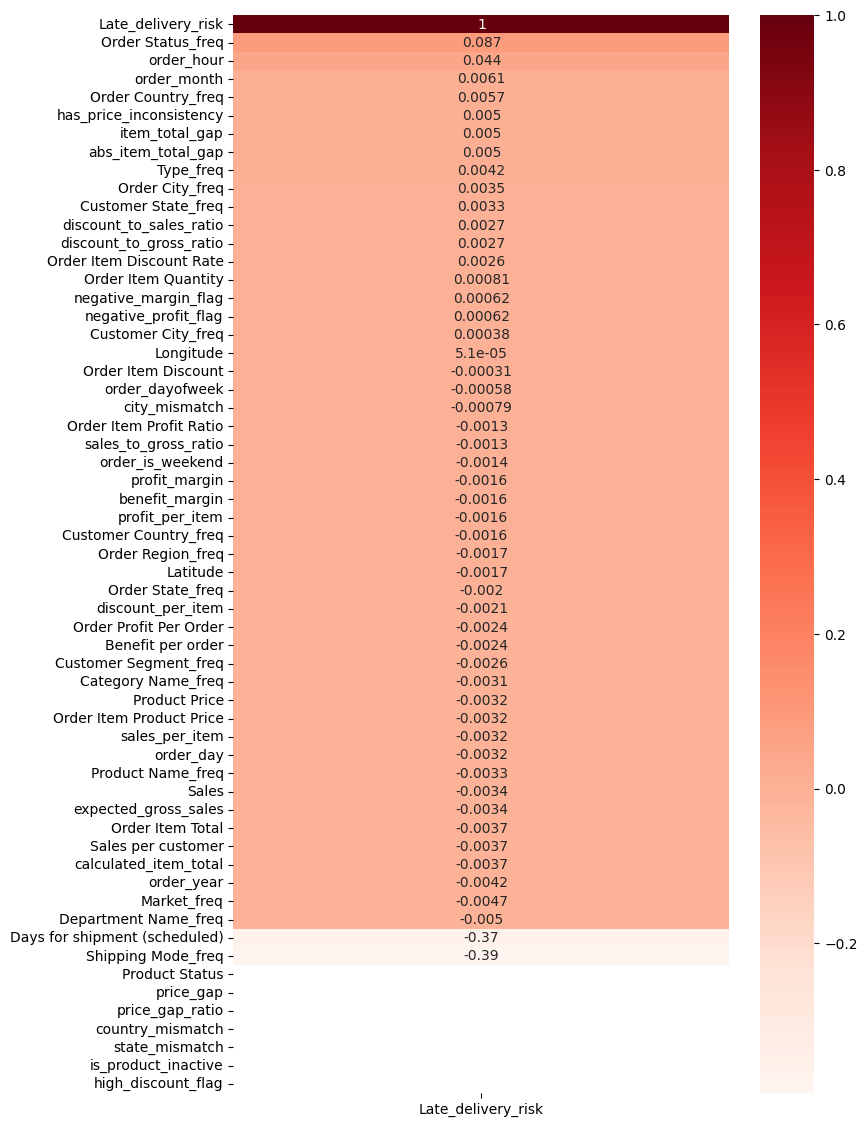

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

train_corr_df = X_train_processed.copy()
train_corr_df['Late_delivery_risk'] = y_train.values

target_correlation = (
    train_corr_df
    .corr(numeric_only=True)[['Late_delivery_risk']]
    .sort_values(by='Late_delivery_risk', ascending=False)
)
plt.figure(figsize=(8,14))
sns.heatmap(target_correlation, annot=True, cmap=plt.cm.Reds)
plt.show()


### Data Reduction

In [ ]:
# Data Cube Aggregation

# Atribut Subset Selection

# Numerosity Reduction

# Dimensionality Reduction


### Model Selection

In [ ]:
from 

SyntaxError: invalid syntax (681706079.py, line 1)

### Model Training 

### Model Tuning

## Fraudness